## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import random
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

from matplotlib import animation
from IPython.display import HTML
from IPython.display import Image, display

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Dataset - Little Artificial English-like Language

In [3]:
pronouns = ['I', 'You', 'He', 'She', 'We', 'They', 'Human', 'Everyone', 'Someone', 'Nobody', 'Anybody', 'Everybody']
animals = ['Dog', 'Cat', 'Bird', 'Fish', 'Elephant', 'Lion', 'Tiger', 'Bear', 'Rabbit', 'Horse', 'Cow', 'Sheep', 'Pig']
foods = ['Apple', 'Bread', 'Meat', 'Cheese', 'Rice', 'Pasta', 'Vegetables', 'Fruits', 'Eggs', 'Fish', 'Chicken', 'Soup', 'Cake', 'Pizza', 'Salad', 'Sandwich', 'Steak', 'Pancakes', 'Waffles', 'Ice-Cream']
beverages = ['Water', 'Milk', 'Juice', 'Coffee', 'Tea', 'Soda', 'Beer', 'Wine', 'Smoothie', 'Cocktail', 'Lemonade', 'Hot-Chocolate', 'Iced-Tea', 'Energy-Drink', 'Sparkling-Water', 'Cider', 'Kombucha', 'Protein-Shake', 'Herbal-Tea', 'Mocktail']

adverbs = ['quickly', 'usually', 'often', 'always', 'never', 'sometimes', 'rarely', 'seldom', 'frequently', 'occasionally', 'regularly', 'constantly', 'periodically', 'intermittently', 'sporadically', 'gradually', 'suddenly', 'abruptly', 'immediately', 'instantly', 'similarly', 'differently', 'uniquely', 'distinctly', 'specifically', 'generally', 'broadly', 'narrowly', 'precisely', 'accurately', 'approximately', 'roughly', 'exactly', 'clearly', 'obviously', 'evidently', 'apparently', 'visibly']

food_verbs = ['eat', 'like', 'hate', 'prefer', 'store', 'dislike', 'want', 'deposit']
drink_verbs = ['drink', 'like', 'hate', 'prefer', 'store', 'dislike', 'want', 'deposit', 'empty', 'full']
animal_verbs = ['see', 'like', 'love', 'feed', 'pat', 'hug', 'embrace', 'abandon', 'hit']

semantic_frames = [
    (pronouns + animals, food_verbs, foods),
    # Type 1: Food Preference
    (pronouns, drink_verbs, beverages),
    # Type 2: Beverage Preference
    (pronouns, animal_verbs, animals),
    # Type 3: Animal Interaction
]

vocab = list(set(pronouns + animals + foods + beverages + adverbs + 
                 food_verbs + drink_verbs + animal_verbs))
print(f"Vocab size: {len(vocab)}")

def generate_semantic_sentence(sentence_type):
    subj_list, verb_list, obj_list = random.choice(semantic_frames)
    
    subj = random.choice(subj_list)
    verb = random.choice(verb_list)
    obj = random.choice(obj_list)
    adv = random.choice(adverbs)
    
    match sentence_type:
        case 'A': # Subj + Adv + Verb + Obj (Standard)
            return f"{subj} {adv} {verb} {obj}"
        case 'B': # Adv + Subj + Verb + Obj (Fronted Adverb)
            return f"{adv} {subj} {verb} {obj}"
        case 'C': # Subj + Verb + Adv + Obj (Mid-Adverb)
            return f"{subj} {verb} {adv} {obj}"
        case _:
            raise ValueError("Invalid type")

for _ in range(3):
    print(generate_semantic_sentence('A'))

Vocab size: 121
He instantly drink Hot-Chocolate
Everybody narrowly deposit Sandwich
Everyone approximately like Kombucha


In [4]:
def sentence_to_ids(sentence, vocab):
    words = sentence.split()
    return [vocab.index(word) for word in words]

class ALToyDataset(Dataset):
    def __init__(self, num_samples):
        super().__init__()
        self.num_samples = num_samples
        self.sentences = [
            generate_semantic_sentence(random.choice(['A', 'B', 'C'])) 
            for _ in range(num_samples)
        ]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        ids = sentence_to_ids(sentence, vocab)
        return torch.tensor(ids, dtype=torch.long)

In [5]:
dataset = ALToyDataset(num_samples=50000)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(dataset), len(dataloader))

for x in dataloader:
    print(x.shape)
    print(x)
    break

50000 1563
torch.Size([32, 4])
tensor([[ 54,   3,  15,   2],
        [107,  81,  89, 106],
        [ 41,  38,  15, 116],
        [ 25,   4,  15, 103],
        [  6,  46,  14,  72],
        [ 62, 108,  86,  49],
        [ 26, 102,   0, 101],
        [ 13,  56,  30,  48],
        [110,  26,  66,  69],
        [ 81,  44,  15, 118],
        [ 51,  13,  34,  83],
        [ 62,   0,  97,  64],
        [ 54,  33,  39,  80],
        [ 55,  15,  40,  76],
        [ 58,  21,  86,  18],
        [ 26,  99, 115,  91],
        [ 26,  14,  87,  52],
        [ 45,  78,  86, 100],
        [104,  79,  97, 105],
        [ 13,  51,   1, 100],
        [ 58,  81,   9,  42],
        [ 55,  87,  78,  91],
        [ 93,  96,   1,  50],
        [ 45, 112,  97,  42],
        [ 81, 102,   0, 113],
        [ 39,  82, 102, 113],
        [ 61,  45,  90,  18],
        [ 82,  28,  66,  69],
        [  6,   1, 111,  85],
        [  4,  25,  33, 120],
        [ 55,  23,  14,  18],
        [ 79,  94,  34,  54]])


## NN

In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [19]:
class FLMDenoiser(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, num_heads=16, num_layers=3):
        super().__init__()
        self.vocab_size = vocab_size

        self.input_proj = nn.Linear(vocab_size, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, 4, embed_dim))  # seq_len = 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(embed_dim),
            nn.Linear(embed_dim, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim)
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim*4, 
            batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.out_proj = nn.Linear(embed_dim, vocab_size)
    
    def forward(self, It, t):
        # It: (batch_size, seq_len, vocab_size)
        x = self.input_proj(It)  # (batch_size, seq_len, embed_dim)

        time_emb = self.time_mlp(t).unsqueeze(1)  # (batch_size, 1, embed_dim)
        x = x + self.pos_embedding + time_emb 

        hidden = self.transformer(x)
        logits = self.out_proj(hidden)

        return logits

In [8]:
sample_model = FLMDenoiser(vocab_size=len(vocab)).to(device)
sample_input = torch.randn(2, 4, len(vocab)).to(device)
sample_time = torch.randint(0, 1000, (2,), dtype=torch.long).to(device)

print(sample_model(sample_input, sample_time).shape)  # Should output (2, 4, vocab_size)

torch.Size([2, 4, 121])


## Training and Sampling

In [9]:
def compute_flm_loss(model, input_ids, vocab_size, time_warper=lambda t: t):
    B, L = input_ids.shape
    input_ids = input_ids.to(device)

    x1 = F.one_hot(input_ids, num_classes=vocab_size).float()  # (B, L, vocab_size)

    x0 = torch.randn_like(x1).to(device)  # (B, L, vocab_size)

    t = torch.rand(B, 1, 1, device=device)  # (B, 1, 1)
    t_warp = time_warper(t)  # (B, 1, 1)

    It = t_warp * x1 + (1 - t_warp) * x0  # (B, L, vocab_size)

    logits = model(It, t_warp.squeeze(-1).squeeze(-1))

    loss = F.cross_entropy(logits.view(-1, vocab_size), input_ids.view(-1))
    return loss

In [10]:
@torch.no_grad()
def sample_flm_text(model, vocab, num_samples=5, seq_len=4, num_steps=50, time_warper=lambda t: t):
    model.eval()
    vocab_size = len(vocab)
    
    xt = torch.randn(num_samples, seq_len, vocab_size, device=device)  # Start from noise

    t_seq = torch.linspace(0, 1.0, num_steps + 1, device=device)

    for i in range(num_steps):
        t_curr = t_seq[i].item()
        t_next = t_seq[i + 1].item()

        t_curr_warp = time_warper(torch.tensor([t_curr], device=device)).item()
        t_next_warp = time_warper(torch.tensor([t_next], device=device)).item()

        if t_curr >= 1.0:
            break

        t_tensor = torch.full((num_samples,), t_curr, device=device)
        t_warp = time_warper(t_tensor)

        logits = model(xt, t_warp)
        x1_hat = F.softmax(logits, dim=-1)

        bt = (x1_hat - xt) / (1.0 - t_curr_warp)

        xt = xt + bt * (t_next_warp - t_curr_warp)
    
    sample_ids = torch.argmax(xt, dim=-1)  # (num_samples, seq_len)
    sample_sentences = []
    for ids in sample_ids:
        words = [vocab[i] for i in ids.cpu().numpy()]
        sample_sentences.append(' '.join(words))
        
    return sample_sentences

In [11]:
sample_flm_text(sample_model, vocab, num_samples=5, seq_len=4, num_steps=50)

['hug Salad Cow Protein-Shake',
 'hug Salad Cow Protein-Shake',
 'hug Salad Cow Protein-Shake',
 'hug Salad Cow Protein-Shake',
 'hug Salad Cow Protein-Shake']

## Training on Linear Timestep

In [20]:
epochs = 50
vocab_size = len(vocab)
model = FLMDenoiser(vocab_size=vocab_size).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

100%|██████████| 1563/1563 [00:25<00:00, 61.53it/s]


Epoch 1, Average Loss: 3.7068885126254227


100%|██████████| 1563/1563 [00:25<00:00, 61.77it/s]


Epoch 2, Average Loss: 3.0842485365315424


100%|██████████| 1563/1563 [00:26<00:00, 59.09it/s]


...

Epoch 48, Average Loss: 2.604692183315792


100%|██████████| 1563/1563 [00:14<00:00, 105.16it/s]


Epoch 49, Average Loss: 2.6126728983773533


100%|██████████| 1563/1563 [00:14<00:00, 109.30it/s]

Epoch 50, Average Loss: 2.616738109884549


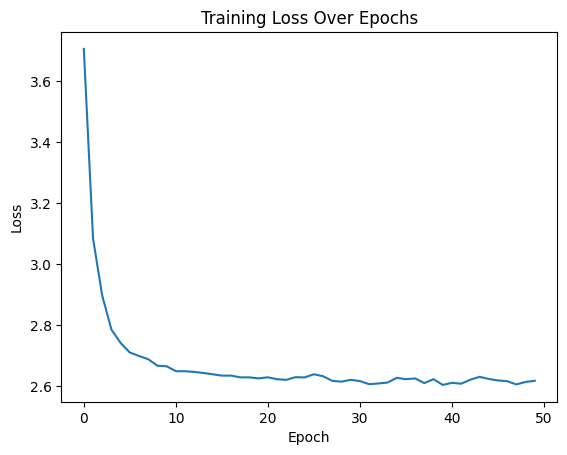

In [21]:
model.train()
history = []
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for batch in tqdm(dataloader):
        optimizer.zero_grad()
        loss = compute_flm_loss(model, batch, vocab_size)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Average Loss: {total_loss / len(dataloader)}")
    history.append(total_loss / len(dataloader))

plt.plot(history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [22]:
generated_sentences = sample_flm_text(model, vocab, num_samples=10, seq_len=4, num_steps=50)

for sentence in generated_sentences:
    print(sentence)

Cat visibly want Eggs
Someone clearly always Energy-Drink
sporadically Anybody see Bird
I often want Pizza
occasionally She dislike Ice-Cream
He hug apparently Cheese
They deposit precisely Water
Anybody evidently dislike Cocktail
Nobody feed full Cocktail
He want love Cat


In [ ]:
import numpy as np

ALL_SUBJ = set(pronouns + animals)
ALL_ADV = set(adverbs)
ALL_VERB = set(food_verbs + drink_verbs + animal_verbs)
ALL_OBJ = set(foods + beverages + animals)

def evaluate_single_sentence(sentence):
    """
    Returns a tuple (is_syntax_valid, is_semantic_valid) for the given sentence.
    """
    words = sentence.strip().split()
        
    w1, w2, w3, w4 = words
    
    subj, adv, verb, obj = None, None, None, None
    is_syntax_valid = False
    
    # [Syntax Rule 2] Sentence structure validation based on predefined patterns
    # Type A: Subj + Adv + Verb + Obj
    if (w1 in ALL_SUBJ) and (w2 in ALL_ADV) and (w3 in ALL_VERB) and (w4 in ALL_OBJ):
        subj, adv, verb, obj = w1, w2, w3, w4
        is_syntax_valid = True
    # Type B: Adv + Subj + Verb + Obj
    elif (w1 in ALL_ADV) and (w2 in ALL_SUBJ) and (w3 in ALL_VERB) and (w4 in ALL_OBJ):
        adv, subj, verb, obj = w1, w2, w3, w4
        is_syntax_valid = True
    # Type C: Subj + Verb + Adv + Obj
    elif (w1 in ALL_SUBJ) and (w2 in ALL_VERB) and (w3 in ALL_ADV) and (w4 in ALL_OBJ):
        subj, verb, adv, obj = w1, w3, w2, w4
        is_syntax_valid = True
        
    # If the syntax is invalid, we cannot proceed to semantic validation
    if not is_syntax_valid:
        return False, False
        
    # [Semantic Rule] Check if the (subj, verb, obj) combination is valid based on predefined semantic frames
    is_semantic_valid = False
    for valid_subjs, valid_verbs, valid_objs in semantic_frames:
        if (subj in valid_subjs) and (verb in valid_verbs) and (obj in valid_objs):
            is_semantic_valid = True
            break
            
    return is_syntax_valid, is_semantic_valid


def evaluate_batch(generated_sentences):
    """
    Evaluates a batch of generated sentences for syntax and semantic accuracy.
    """
    syntax_results = []
    semantic_results = []
    
    for sent in generated_sentences:
        syn_ok, sem_ok = evaluate_single_sentence(sent)
        syntax_results.append(syn_ok)
        semantic_results.append(sem_ok)
        
    syntax_acc = np.mean(syntax_results) * 100
    semantic_acc = np.mean(semantic_results) * 100
    
    # Conditional Semantic Accuracy (only for syntactically valid sentences)
    valid_syntax_count = np.sum(syntax_results)
    cond_semantic_acc = (np.sum(semantic_results) / valid_syntax_count * 100) if valid_syntax_count > 0 else 0.0
    
    return {
        "Syntax Accuracy": syntax_acc,
        "Semantic Accuracy": semantic_acc,
        "Conditional Semantic Accuracy": cond_semantic_acc
    }

In [24]:
NUM_SAMPLES = 2000
NUM_STEPS = 20

test_sentences = sample_flm_text(model, vocab, num_samples=NUM_SAMPLES, seq_len=4, num_steps=NUM_STEPS)

for i, sentence in enumerate(test_sentences):
    print(f"{i}: {sentence}")

    if i >= 9:  # Limit to first 10 sentences for display
        break

result = evaluate_batch(test_sentences)
print()
print(f"Evaluation Results - # of Samples: {NUM_SAMPLES}, # of Steps: {NUM_STEPS}")
for metric, value in result.items():
    print(f"  {metric}: {value:.2f}%")

0: sometimes They dislike Fish
1: They similarly accurately Lemonade
2: Someone hit immediately Rabbit
3: He always feed Pig
4: Cat eat sometimes Pig
5: Nobody exactly full Juice
6: He hate occasionally Herbal-Tea
7: You store deposit Fruits
8: sporadically We store Fish
9: clearly like evidently Sandwich

Evaluation Results - # of Samples: 2000, # of Steps: 20
  Syntax Accuracy: 76.20%
  Semantic Accuracy: 42.75%
  Conditional Semantic Accuracy: 56.10%


## Training on Time Reparameterization

In [25]:
vocab_size = len(vocab)
gamma = 1.0 + 0.45 * torch.log(torch.tensor(vocab_size / 10.0, dtype=torch.float32))

def time_warper(t):
    return torch.clamp(1.0 - torch.pow(1.0 - t + 1e-7, gamma), min=0.0, max=1.0)

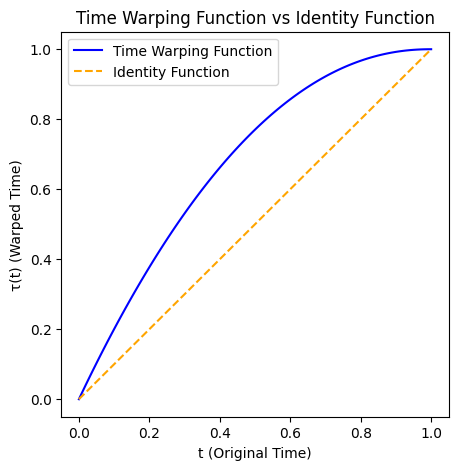

In [26]:
plt.figure(figsize=(5, 5))
t_values = torch.linspace(0, 1.0, 100)
tau_values = time_warper(t_values)
plt.plot(t_values.numpy(), tau_values.numpy(), label='Time Warping Function', color='blue')
plt.plot(t_values.numpy(), t_values.numpy(), label='Identity Function', color='orange', linestyle='--')
plt.title('Time Warping Function vs Identity Function')
plt.xlabel('t (Original Time)')
plt.ylabel('τ(t) (Warped Time)')
plt.legend()
plt.show()

In [27]:
epochs = 50
vocab_size = len(vocab)
rep_model = FLMDenoiser(vocab_size=vocab_size).to(device)
optimizer = optim.AdamW(rep_model.parameters(), lr=1e-3)

100%|██████████| 1563/1563 [00:14<00:00, 106.38it/s]


Epoch 1, Average Loss: 2.690192773070613


100%|██████████| 1563/1563 [00:14<00:00, 108.58it/s]


Epoch 2, Average Loss: 1.8990906567353891


100%|██████████| 1563/1563 [00:14<00:00, 106.62it/s]


...

Epoch 48, Average Loss: 1.6217718152228031


100%|██████████| 1563/1563 [00:14<00:00, 106.61it/s]


Epoch 49, Average Loss: 1.636366634207205


100%|██████████| 1563/1563 [00:14<00:00, 106.60it/s]


Epoch 50, Average Loss: 1.6105333927420569


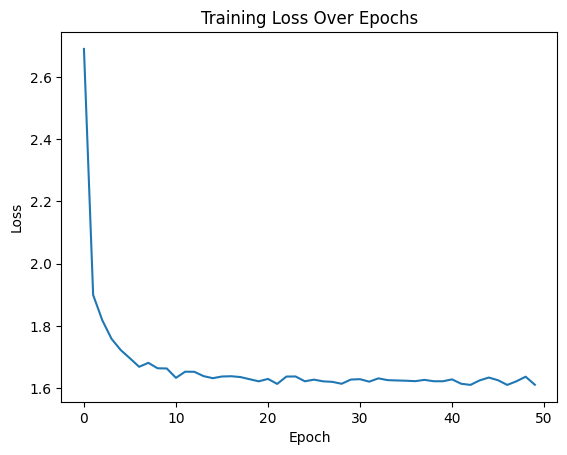

In [28]:
rep_model.train()
history = []
for epoch in range(1, epochs + 1):
    total_loss = 0.0
    for batch in tqdm(dataloader):
        optimizer.zero_grad()
        loss = compute_flm_loss(rep_model, batch, vocab_size, time_warper=time_warper)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}, Average Loss: {total_loss / len(dataloader)}")
    history.append(total_loss / len(dataloader))

plt.plot(history)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [29]:
NUM_SAMPLES = 2000
NUM_STEPS = 20

test_sentences = sample_flm_text(rep_model, vocab, num_samples=NUM_SAMPLES, seq_len=4, num_steps=NUM_STEPS, time_warper=time_warper)

for i, sentence in enumerate(test_sentences):
    print(f"{i}: {sentence}")

    if i >= 9:  # Limit to first 10 sentences for display
        break

result = evaluate_batch(test_sentences)
print()
print(f"Evaluation Results - # of Samples: {NUM_SAMPLES}, # of Steps: {NUM_STEPS}")
for metric, value in result.items():
    print(f"  {metric}: {value:.2f}%")

0: evidently I full Meat
1: Someone hate instantly Cider
2: Someone distinctly like Chicken
3: suddenly They drink Soda
4: Everyone uniquely store Sparkling-Water
5: never Nobody want Soup
6: frequently Anybody hate Rice
7: Everybody store frequently Herbal-Tea
8: Anybody never deposit Sparkling-Water
9: visibly Someone love Lion

Evaluation Results - # of Samples: 2000, # of Steps: 20
  Syntax Accuracy: 86.20%
  Semantic Accuracy: 47.50%
  Conditional Semantic Accuracy: 55.10%


## Timeline Analysis

In [30]:
@torch.no_grad()
def sample_flm_text_timeline(
    model,
    vocab,
    num_samples=2000,
    seq_len=4,
    num_steps=20,
    time_warper=lambda t: t,
):
    model.eval()
    vocab_size = len(vocab)

    xt = torch.randn(num_samples, seq_len, vocab_size, device=device)

    t_seq = torch.linspace(0, 1.0, num_steps + 1, device=device)

    history = []

    for i in range(num_steps):

        t_curr = t_seq[i].item()
        t_next = t_seq[i + 1].item()

        t_curr_warp = time_warper(torch.tensor([t_curr], device=device)).item()
        t_next_warp = time_warper(torch.tensor([t_next], device=device)).item()

        t_tensor = torch.full((num_samples,), t_curr, device=device)
        t_warp = time_warper(t_tensor)

        logits = model(xt, t_warp)
        x1_hat = F.softmax(logits, dim=-1)

        # ---------- save current prediction ----------
        ids = torch.argmax(x1_hat, dim=-1)
        history.append(ids.cpu())

        # ---------- Euler update ----------
        bt = (x1_hat - xt) / (1.0 - t_curr_warp)
        xt = xt + bt * (t_next_warp - t_curr_warp)

    return history

In [ ]:
def evaluate_timeline(history, vocab):

    timeline = []

    prev_ids = None

    for step, ids_tensor in enumerate(history):

        sentences = []

        ids_np = ids_tensor.numpy()

        for ids in ids_np:
            words = [vocab[i] for i in ids]
            sentences.append(" ".join(words))

        result = evaluate_batch(sentences)

        # ------------------------
        # Token Change Rate
        # ------------------------

        if prev_ids is None:
            change_rate = 100.0
        else:
            change_rate = (
                (ids_tensor != prev_ids)
                .float()
                .mean()
                .item()
                * 100
            )

        prev_ids = ids_tensor.clone()

        result["Token Change Rate"] = change_rate
        result["Step"] = step

        timeline.append(result)

    return timeline

In [39]:
history = sample_flm_text_timeline(
    rep_model,
    vocab,
    num_samples=10000,
    num_steps=20,
    time_warper=time_warper,
)

timeline = evaluate_timeline(history, vocab)

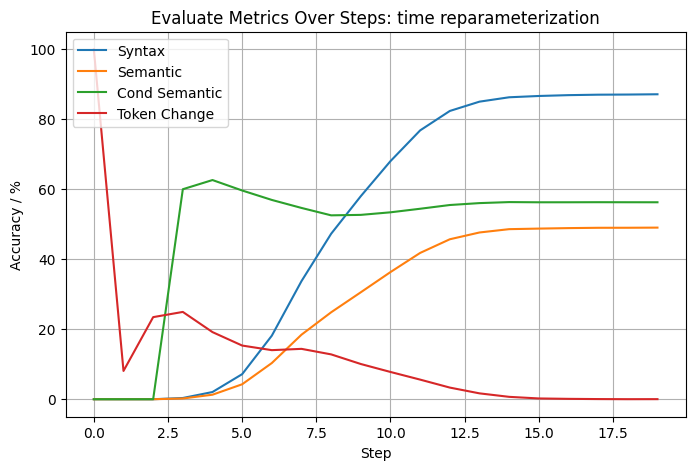

In [ ]:
import matplotlib.pyplot as plt

steps = [x["Step"] for x in timeline]

syntax = [x["Syntax Accuracy"] for x in timeline]
semantic = [x["Semantic Accuracy"] for x in timeline]
cond_sem = [x["Conditional Semantic Accuracy"] for x in timeline]
change = [x["Token Change Rate"] for x in timeline]

plt.figure(figsize=(8,5))

plt.plot(steps, syntax, label="Syntax")
plt.plot(steps, semantic, label="Semantic")
plt.plot(steps, cond_sem, label="Cond Semantic")
plt.plot(steps, change, label="Token Change")

plt.xlabel("Step")
plt.ylabel("Accuracy / %")
plt.title("Evaluate Metrics Over Steps: time reparameterization")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
history = sample_flm_text_timeline(
    model,
    vocab,
    num_samples=10000,
    num_steps=20,
)

timeline = evaluate_timeline(history, vocab)

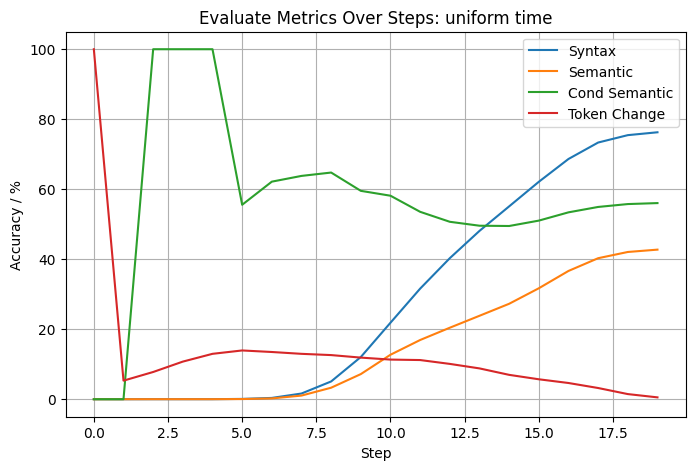

In [43]:
import matplotlib.pyplot as plt

steps = [x["Step"] for x in timeline]

syntax = [x["Syntax Accuracy"] for x in timeline]
semantic = [x["Semantic Accuracy"] for x in timeline]
cond_sem = [x["Conditional Semantic Accuracy"] for x in timeline]
change = [x["Token Change Rate"] for x in timeline]

plt.figure(figsize=(8,5))

plt.plot(steps, syntax, label="Syntax")
plt.plot(steps, semantic, label="Semantic")
plt.plot(steps, cond_sem, label="Cond Semantic")
plt.plot(steps, change, label="Token Change")

plt.xlabel("Step")
plt.ylabel("Accuracy / %")
plt.title("Evaluate Metrics Over Steps: uniform time")
plt.legend()
plt.grid(True)
plt.show()